In [1]:
import numpy as np
import dask , dask.distributed
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import cmocean.cm as cmo
import warnings
import seaborn as sns
warnings.simplefilter('ignore')
import dask_jobqueue
from astropy.convolution import Box2DKernel, convolve
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter,
                                LatitudeLocator, LongitudeLocator)
import matplotlib.colors as colors
import pandas as pd
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable


# Custom functions (assumed in your local directory)
from fix_grid import fix_grid #
from useful_calculations import weighted_means
import pickle
import matplotlib.colors as mcolors


In [2]:
###Load datasets
#ds_mom=xr.open_dataset('/gxfs_work/geomar/smomw577/mesoscale_eddies/MOM5_concat/0181-0190/MOM5_monthly_0181-0190_noice_all.nc')
pathp='/gxfs_home/geomar/smomw577/plots/Boxcar/0181-0190/'
pathf='/gxfs_work/geomar/smomw577/mesoscale_eddies/BOX_filtered/0181-0190/'
dsa=xr.open_dataset(pathf+'3x3box_median_anomaly_monthly_0181-0190_all.nc').chunk({"yt_ocean": 200, "xt_ocean": 200, "time": 10})
grid=xr.open_dataset(pathf+'ocean_grid.nc')

combined_mask_ctrl=xr.open_dataset(pathf+'categorization_simple.nc').corr_o2_stf_dic_stf
combined_mask_cc=xr.open_dataset(pathf+'categorization_simple_1PctTo2X.nc').corr_o2_stf_dic_stf_1PctTo2X
dsa_wind=xr.open_dataset(pathf+'3x3box_median_anomaly_monthly_0181-0190_wind.nc').chunk({"yt_ocean": 200, "xt_ocean": 200, "time": 10})#3x3box_median_anomaly_monthly_1PctTo2X_0181-0190_wind.nc

In [128]:
co2=dsa.dic_stf#.isel(time=slice(0,40))
o2=dsa.o2_stf#.isel(time=slice(0,40))
sens=dsa.sens_heat#.isel(time=slice(0,40))
SST=dsa.SST#.isel(time=slice(0,40))
wind=dsa_wind.wind_stress#.isel(time=slice(0,40))

In [75]:
wind=wind.where(SST>0).where((wind>=(wind.mean()-wind.std()).values)&(wind<=(wind.mean()+wind.std()).values))
co2=co2.where(SST>0).where((co2>=(co2.mean()-co2.std()).values)&(co2<=(co2.mean()+co2.std()).values))
SST=SST.where(SST>0).where((SST>=(SST.mean()-SST.std()).values)&(SST<=(SST.mean()+SST.std()).values))

In [76]:
mask = wind.notnull() & SST.notnull()

wind_clean = wind.where(mask)
#co2_clean = co2.where(mask)
SST_clean=SST.where(mask)

In [77]:
wind_l = wind_clean.stack(points=("yt_ocean", "xt_ocean"))
#co2_l = co2_clean.stack(points=("yt_ocean", "xt_ocean"))
SST_l = SST_clean.stack(points=("yt_ocean", "xt_ocean"))

In [78]:
x=SST_l
y=wind_l
#x=wind_l#.where((wind_l>=(wind_l.mean()-2*wind_l.std()).values)&(wind_l<=(wind_l.mean()+2*wind_l.std()).values))
#y=co2_l#.where(x, drop=True)
#x=x.where(y, drop=True)
x=x.dropna(dim='points')
y=y.dropna(dim='points')

In [79]:
#mask = ~np.isnan(x) & ~np.isnan(y)
#x=x[mask]
#y=y[mask]
#

bins = np.linspace(x.min().compute(), x.max().compute(), 20)

y_binned = y.groupby_bins(x, bins)#.mean()

data_per_bin = [group.values for _, group in y_binned]

mean_per_bin = np.array([d.mean() for d in data_per_bin])
bin_centers = 0.5 * (bins[:-1] + bins[1:])
x_positions = bin_centers
m, b = np.polyfit(x_positions, mean_per_bin, 1)
y_fit = m * x_positions + b

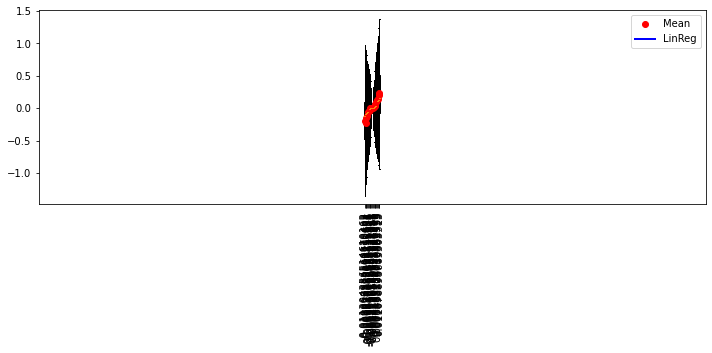

In [10]:
plt.figure(figsize=(10,5))
# Boxplots
plt.boxplot(
    data_per_bin,
    positions=bin_centers,
    widths=np.diff(bins)*0.8,
    showfliers=False
)

# Mean dots
plt.plot(x_positions, mean_per_bin, 'o', color='red', label='Mean')

# Linear regression line
plt.plot(x_positions, y_fit, '-', color='blue', linewidth=2, label='LinReg')

plt.xticks(rotation=90)
#plt.xlabel("SST")
#plt.ylabel("sens heat")
plt.legend()
plt.tight_layout()

In [80]:
xmean=x.mean().values
ymean=y.mean().values

Text(0, 0.5, 'wind ano')

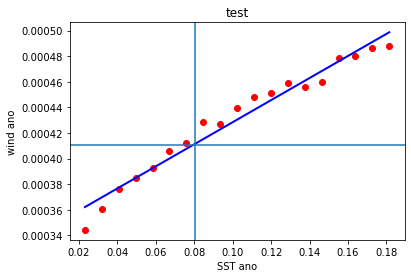

In [81]:
plt.plot(x_positions, mean_per_bin, 'o', color='red', label='Mean per bin')
plt.plot(x_positions, y_fit, '-', color='blue', linewidth=2, label='Linear fit')
plt.axhline(ymean)
plt.axvline(xmean)
plt.title('test')
plt.xlabel('SST ano')
plt.ylabel('wind ano')

In [82]:
x_val = x.mean().values  # example, like 15 °C or wind value
y_val = m * x_val + b
print(f"Predicted y for x={x_val} is y={y_val:.2f}")

Predicted y for x=0.08032623678445816 is y=0.00


In [83]:
ymean

array(0.00041103)

In [50]:
xmean

array(0.00085534)

In [84]:
y_val/ymean

1.001169987088895

(array([  9482.,  17195.,  35853.,  98217., 557030., 959300., 298865.,
        111808.,  53968.,  29341.]),
 array([-0.01192605, -0.00956361, -0.00720116, -0.00483872, -0.00247628,
        -0.00011383,  0.00224861,  0.00461105,  0.0069735 ,  0.00933594,
         0.01169839]),
 <BarContainer object of 10 artists>)

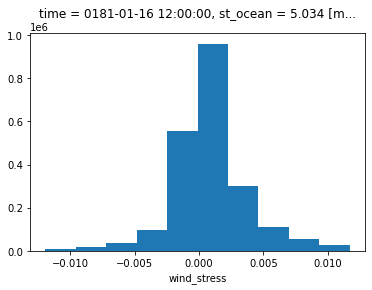

In [52]:
x.plot.hist()

In [127]:
def percentage(var1, var2):
    
    r = xr.corr(var1, var2, dim="time")
    r2 = r**2    
    r2_weighted_mean = r2.weighted(grid.area_t.fillna(0)).mean(("xt_ocean", "yt_ocean"))
    return r2_weighted_mean

In [130]:
print(percentage(wind, o2).values)

0.06915365552289425


In [131]:
print(percentage(wind, co2).values)

0.09219433710385067


In [132]:
print(percentage(sens, co2).values)

0.16751077137552195


In [133]:
print(percentage(sens, o2).values)

0.15429878350903845


In [134]:
print(percentage(sens, SST).values)

0.6718119908478835


In [135]:
print(percentage(wind, SST).values)

0.16303070818457405


In [136]:
print(percentage(dsa.evap_heat, SST).values)

0.7077815968349283


In [143]:
print(percentage(SST, co2).values)

0.16267195493785738


In [144]:
print(percentage(SST, o2).values)

0.13918466934287335


In [145]:
print(percentage(dsa.jp_all, o2).values)

0.12009456762612328


In [146]:
print(percentage(dsa.jp_all, co2).values)

0.049514812539010154


In [148]:
xr.corr(wind, co2).weighted(grid.area_t.fillna(0)).mean(("xt_ocean", "yt_ocean")).values

array(0.10714819)

In [149]:
xr.corr(wind, o2).weighted(grid.area_t.fillna(0)).mean(("xt_ocean", "yt_ocean")).values

array(0.08331718)